# Sung Tunable Custom Circuit Analysis

This notebook is the **canonical end-to-end walkthrough** for the Sung et al. tunable-coupler device implemented with `ScQubitsMimic`.

It consolidates the earlier custom-circuit walkthrough and the resonant-`ZZ` notebook into one top-to-bottom flow:

1. paper-to-code circuit translation,
2. symbolic model inspection,
3. hierarchical subsystem configuration and validation,
4. 1D subsystem-frequency sweeps,
5. 2D exact `ZZ(CPLR freq, QB2 freq)` analysis and its resonant/dressed-spectrum views.

**Source note**
- This notebook follows **Sung et al.**, *“Realization of high-fidelity CZ and ZZ-free iSWAP gates with a tunable coupler”*.
- Fig. 7 supplies the fitted Josephson energies for `QB1`, `CPLR`, and `QB2`.
- Appendix Q / Table VI supplies the physical capacitances `C1`, `Cc`, `C2`, `C1c`, `C2c`, and `C12`.
- In `ScQubitsMimic`, branch `EC` encodes branch capacitance through `C = 1 / (8 EC)`, so a physical capacitance `C` becomes `EC_branch = (e^2 / 2 C h) / 4`.
- With fixed-frequency `QB1`, the generated external flux symbols are `Φ1` for the coupler loop and `Φ2` for the `QB2` loop.


In [1]:
using ScQubitsMimic
using CairoMakie
using Statistics
using Printf

const ELEMENTARY_CHARGE = 1.602176634e-19
const PLANCK_CONSTANT = 6.62607015e-34
const JJ_EC_NEGLIGIBLE = 1.0e6

physical_ec_from_capacitance_ff(C_ff) = ELEMENTARY_CHARGE^2 / (2 * C_ff * 1e-15 * PLANCK_CONSTANT) / 1e9
branch_ec_from_capacitance_ff(C_ff) = physical_ec_from_capacitance_ff(C_ff) / 4
flux_bias_to_rad(bias) = 2π * bias

const QB1_EJ_GHz = 12.2
const CPLR_EJ1_GHz = 46.0
const CPLR_EJ2_GHz = 25.0
const QB2_EJ1_GHz = 13.0
const QB2_EJ2_GHz = 2.8

const QB1_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(95.0)
const CPLR_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(228.0)
const QB2_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(98.0)
const QB1_CPLR_BRANCH_EC = branch_ec_from_capacitance_ff(5.36)
const CPLR_QB2_BRANCH_EC = branch_ec_from_capacitance_ff(5.36)
const QB1_QB2_BRANCH_EC = branch_ec_from_capacitance_ff(0.125)

const EXPECTED_CAPACITANCE_MATRIX = [
    2.593800082548214 -0.13835664798187222 -0.0032266009324130643;
   -0.13835664798187222 6.162033646685175 -0.13835664798187222;
   -0.0032266009324130643 -0.13835664798187222 2.671238629926127;
]

const COUPLER_FLUX_PARAM = :Φ1
const QB2_FLUX_PARAM = :Φ2
const DEFAULT_NCUT = 6
const DEFAULT_HIERARCHY = [[1], [2], [3]]
const DEFAULT_TRUNC_DIMS = [3, 3, 3]
const DEFAULT_EVALS_COUNT = prod(DEFAULT_TRUNC_DIMS)
const DEFAULT_PHI1_GRID = collect(range(-0.5, 0.0; length=81))
const DEFAULT_PHI2_GRID = collect(range(-0.5, 0.0; length=81))
const ZZ_COLOR_SCALE_KHZ = 5.0
const ZZ_COLORBAR_TICKS_KHZ = [-500.0, -50.0, -5.0, 0.0, 5.0, 50.0, 500.0]

const GROUND_LABEL = (1, 1, 1)
const Q1_LABEL = (2, 1, 1)
const CPLR_LABEL = (1, 2, 1)
const Q2_LABEL = (1, 1, 2)
const Q1Q2_LABEL = (2, 1, 2)

const SUNG_EXPERIMENT_CIRCUIT = """
branches:
  - [JJ, 0, 1, EJ=$(QB1_EJ_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 1, 0, EC=$(QB1_GROUND_BRANCH_EC)]
  - [JJ, 0, 2, EJ=$(CPLR_EJ1_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [JJ, 2, 0, EJ=$(CPLR_EJ2_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 2, 0, EC=$(CPLR_GROUND_BRANCH_EC)]
  - [JJ, 0, 3, EJ=$(QB2_EJ1_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [JJ, 3, 0, EJ=$(QB2_EJ2_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 3, 0, EC=$(QB2_GROUND_BRANCH_EC)]
  - [C, 1, 2, EC=$(QB1_CPLR_BRANCH_EC)]
  - [C, 2, 3, EC=$(CPLR_QB2_BRANCH_EC)]
  - [C, 1, 3, EC=$(QB1_QB2_BRANCH_EC)]
"""

function build_sung_circuit(; flux_cplr=0.0, flux_qb2=0.0, ncut=DEFAULT_NCUT)
    circ = Circuit(SUNG_EXPERIMENT_CIRCUIT; ncut=ncut)
    set_param!(circ, COUPLER_FLUX_PARAM, flux_bias_to_rad(flux_cplr))
    set_param!(circ, QB2_FLUX_PARAM, flux_bias_to_rad(flux_qb2))
    return circ
end

function build_hierarchical_hs(; flux_cplr=0.0, flux_qb2=0.0,
                               ncut=DEFAULT_NCUT,
                               trunc_dims=DEFAULT_TRUNC_DIMS)
    return hierarchical_diag(build_sung_circuit(; flux_cplr=flux_cplr, flux_qb2=flux_qb2, ncut=ncut);
        system_hierarchy=DEFAULT_HIERARCHY,
        subsystem_trunc_dims=trunc_dims)
end

function build_configured_hierarchical_circuit(; flux_cplr=0.0, flux_qb2=0.0,
                                               ncut=DEFAULT_NCUT,
                                               trunc_dims=DEFAULT_TRUNC_DIMS)
    circ = build_sung_circuit(; flux_cplr=flux_cplr, flux_qb2=flux_qb2, ncut=ncut)
    configure!(circ;
        system_hierarchy=DEFAULT_HIERARCHY,
        subsystem_trunc_dims=trunc_dims)
    return circ
end

function subsystem_transition_freq(subsys)
    vals = eigenvals(subsys; evals_count=2)
    return vals[2] - vals[1]
end

subsystem_w01s(hs) = (
    qb1 = subsystem_transition_freq(hs.subsystems[1]),
    cplr = subsystem_transition_freq(hs.subsystems[2]),
    qb2 = subsystem_transition_freq(hs.subsystems[3]),
)

function sweep_subsystem_w01s(sweep_param::Symbol, sweep_bias_vals;
                              fixed_bias=(; flux_cplr=0.0, flux_qb2=0.0),
                              trunc_dims=DEFAULT_TRUNC_DIMS,
                              ncut=DEFAULT_NCUT)
    qb1 = Float64[]
    cplr = Float64[]
    qb2 = Float64[]

    for bias in sweep_bias_vals
        flux_cplr = sweep_param === COUPLER_FLUX_PARAM ? bias : fixed_bias.flux_cplr
        flux_qb2 = sweep_param === QB2_FLUX_PARAM ? bias : fixed_bias.flux_qb2
        hs = build_hierarchical_hs(; flux_cplr=flux_cplr, flux_qb2=flux_qb2,
            trunc_dims=trunc_dims, ncut=ncut)
        freqs = subsystem_w01s(hs)
        push!(qb1, freqs.qb1)
        push!(cplr, freqs.cplr)
        push!(qb2, freqs.qb2)
    end

    return (qb1=qb1, cplr=cplr, qb2=qb2)
end

function monotonic_direction(vals; atol=1e-9)
    diffs = diff(vals)
    if all(diffs .>= -atol)
        return :increasing
    elseif all(diffs .<= atol)
        return :decreasing
    else
        return :nonmonotonic
    end
end

function lookup_energy(lookup, bare_label::NTuple{3, Int})
    idx = get(lookup.bare_to_dressed, bare_label, nothing)
    idx === nothing && error("Bare label $(bare_label) missing in sweep lookup")
    return lookup.dressed_evals[idx]
end

function zz_from_lookup(lookup)
    E000 = lookup_energy(lookup, GROUND_LABEL)
    E100 = lookup_energy(lookup, Q1_LABEL)
    E001 = lookup_energy(lookup, Q2_LABEL)
    E101 = lookup_energy(lookup, Q1Q2_LABEL)
    return E101 - E100 - E001 + E000
end

asinh_zz(x_kHz; scale=ZZ_COLOR_SCALE_KHZ) = asinh(x_kHz / scale)

function reshape_sweep_grid(flat_vals, sweep::ParameterSweep;
                            first_param=COUPLER_FLUX_PARAM,
                            second_param=QB2_FLUX_PARAM)
    dims = Tuple(length(sweep.param_vals[name]) for name in sweep.param_order)
    arr = reshape(flat_vals, dims)
    perm = (
        findfirst(==(first_param), sweep.param_order),
        findfirst(==(second_param), sweep.param_order),
    )
    return perm == (1, 2) ? arr : permutedims(arr, perm)
end

function parameter_sweep_zz_qb1_qb2(phi1_vals=DEFAULT_PHI1_GRID, phi2_vals=DEFAULT_PHI2_GRID;
                                    trunc_dims=DEFAULT_TRUNC_DIMS,
                                    ncut=DEFAULT_NCUT,
                                    evals_count=DEFAULT_EVALS_COUNT)
    circ = build_configured_hierarchical_circuit(; flux_cplr=first(phi1_vals), flux_qb2=first(phi2_vals),
        trunc_dims=trunc_dims, ncut=ncut)
    hs0 = circ._hilbert_space

    sweep = ParameterSweep(hs0,
        Dict(COUPLER_FLUX_PARAM => collect(Float64, phi1_vals),
             QB2_FLUX_PARAM => collect(Float64, phi2_vals)),
        (sweep, flux_cplr, flux_qb2) -> begin
            set_param!(circ, COUPLER_FLUX_PARAM, flux_bias_to_rad(flux_cplr))
            set_param!(circ, QB2_FLUX_PARAM, flux_bias_to_rad(flux_qb2))
            sweep.hilbertspace = circ._hilbert_space
        end;
        evals_count=evals_count,
        subsys_update_info=Dict(COUPLER_FLUX_PARAM => [2], QB2_FLUX_PARAM => [3]),
        ignore_low_overlap=true,
        store_lookups=true)

    zz_grid = reshape_sweep_grid(chi_matrix(sweep)[:, 1, 3], sweep)
    lookup_grid = reshape_sweep_grid(sweep.lookups, sweep)
    return sweep, zz_grid, lookup_grid
end

circ1 = build_sung_circuit()


Circuit(SymbolicCircuit(CircuitGraph(Branch[Branch(JJ, 0→1, EJ=12.2, EC=1.0e6), Branch(C, 1→0, EC=0.050974287696471374), Branch(JJ, 0→2, EJ=46.0, EC=1.0e6), Branch(JJ, 2→0, EJ=25.0, EC=1.0e6), Branch(C, 2→0, EC=0.021239286540196405), Branch(JJ, 0→3, EJ=13.0, EC=1.0e6), Branch(JJ, 3→0, EJ=2.8, EC=1.0e6), Branch(C, 3→0, EC=0.04941385031800796), Branch(C, 1→2, EC=0.9034621886501454), Branch(C, 2→3, EC=0.9034621886501454), Branch(C, 1→3, EC=38.74045864931824)], 3, true), [2, 5, 8], [1, 3, 4, 6, 7, 9, 10, 11], [[(1, 1), (2, 1)], [(3, 1), (5, 1)], [(4, 1), (5, -1)], [(6, 1), (8, 1)], [(7, 1), (8, -1)], [(9, 1), (2, -1), (5, 1)], [(10, 1), (5, -1), (8, 1)], [(11, 1), (2, -1), (8, 1)]], [4, 7], [[(4, 1), (3, 1)], [(7, 1), (6, 1)]], Symbolics.Num[φ₁, φ₂, φ₃], Symbolics.Num[φ̇₁, φ̇₂, φ̇₃], Symbolics.Num[2.593800082548214 -0.13835664798187222 -0.0032266009324130643; -0.13835664798187222 6.162033646685175 -0.13835664798187222; -0.0032266009324130643 -0.13835664798187222 2.671238629926127], Symboli

## Circuit Definition And Translation

The circuit below uses explicit `C` branches to represent the Sung et al. Table VI capacitance matrix and keeps JJ-branch capacitance negligible.
This preserves the paper topology `fixed QB1 + tunable CPLR + tunable QB2` while remaining faithful to the codebase branch-capacitance convention.


In [2]:
    println("Paper-derived branch inputs (GHz):")
    println((
        qb1_ground = QB1_GROUND_BRANCH_EC,
        cplr_ground = CPLR_GROUND_BRANCH_EC,
        qb2_ground = QB2_GROUND_BRANCH_EC,
        qb1_cplr = QB1_CPLR_BRANCH_EC,
        cplr_qb2 = CPLR_QB2_BRANCH_EC,
        qb1_qb2 = QB1_QB2_BRANCH_EC,
    ))
    println("External flux symbols: ", external_fluxes(circ1))
    println("Flux loop map: ", sym_external_fluxes(circ1))
    println("Offset-charge symbols: ", offset_charges(circ1))
    println("Variable categories: ", circ1.var_categories)

    C_numeric = ScQubitsMimic._build_capacitance_matrix_numeric(circ1)
    println("Numeric capacitance matrix:\n", C_numeric)
    println("Max |ΔC| vs translated target = ", maximum(abs.(C_numeric .- EXPECTED_CAPACITANCE_MATRIX)))

    @assert length(external_fluxes(circ1)) == 2
    @assert maximum(abs.(C_numeric .- EXPECTED_CAPACITANCE_MATRIX)) < 1e-12


Paper-derived branch inputs (GHz):
(qb1_ground = 0.050974287696471374, cplr_ground = 0.021239286540196405, qb2_ground = 0.04941385031800796, qb1_cplr = 0.9034621886501454, cplr_qb2 = 0.9034621886501454, qb1_qb2 = 38.74045864931824)
External flux symbols: Symbolics.Num[Φ1, Φ2]
Flux loop map: Dict{Symbolics.Num, @NamedTuple{closure_branch::Int64, loop::Vector{Tuple{Int64, Int64}}}}(Φ1 => (closure_branch = 4, loop = [(4, 1), (3, 1)]), Φ2 => (closure_branch = 7, loop = [(7, 1), (6, 1)]))
Offset-charge symbols: Symbolics.Num[ng1, ng2, ng3]
Variable categories: VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])
Numeric capacitance matrix:
[2.593800082548214 -0.13835664798187222 -0.0032266009324130643; -0.13835664798187222 6.162033646685175 -0.13835664798187222; -0.0032266009324130643 -0.13835664798187222 2.671238629926127]
Max |ΔC| vs translated target = 0.0


## Symbolic Lagrangian And Hamiltonian

As in the scqubits custom-circuit tutorial, the first step is to inspect the symbolic model before moving on to hierarchical sweeps.


In [3]:
sym_lagrangian(circ1; vars_type=:node)


2.8cos(Φ2 - φ₃) + 25.0cos(Φ1 - φ₂) + 12.2cos(φ₁) + 13.0cos(φ₃) + 46.0cos(φ₂) + (2.593800082548214(φ̇₁^2) - 0.27671329596374444φ̇₁*φ̇₂ - 0.006453201864826129φ̇₁*φ̇₃ + 6.162033646685175(φ̇₂^2) - 0.27671329596374444φ̇₂*φ̇₃ + 2.671238629926127(φ̇₃^2)) / 2

In [4]:
variable_transformation(circ1)
circ1.var_categories


VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])

In [5]:
sym_hamiltonian(circ1; return_expr=true)


-46.0cos(θ₂) - 2.8cos(Φ2 / 6.283185307179586 - θ₃) - 13.0cos(θ₃) - 12.2cos(θ₁) - 25.0cos(Φ1 / 6.283185307179586 - θ₂) + 0.771999(nθ₁^2) + 0.03475nθ₁*nθ₂ + 0.003665nθ₁*nθ₃ + 0.325337(nθ₂^2) + 0.033744nθ₂*nθ₃ + 0.749592(nθ₃^2)

## Configured Subsystem Introspection

`configure!` attaches a subsystem hierarchy to the circuit and lets us inspect the individual `QB1`, `CPLR`, and `QB2` symbolic Hamiltonians together with their pairwise interactions.


In [6]:
circ_cfg = build_sung_circuit(; ncut=6)
configure!(circ_cfg;
    system_hierarchy=DEFAULT_HIERARCHY,
    subsystem_trunc_dims=DEFAULT_TRUNC_DIMS)

subsystem_exprs = [
    "QB1" => sym_hamiltonian(circ_cfg; subsystem_index=1, return_expr=true),
    "CPLR" => sym_hamiltonian(circ_cfg; subsystem_index=2, return_expr=true),
    "QB2" => sym_hamiltonian(circ_cfg; subsystem_index=3, return_expr=true),
]

interaction_exprs = [
    "QB1-CPLR" => sym_interaction(circ_cfg; subsystem_indices=(1, 2), return_expr=true),
    "CPLR-QB2" => sym_interaction(circ_cfg; subsystem_indices=(2, 3), return_expr=true),
    "QB1-QB2" => sym_interaction(circ_cfg; subsystem_indices=(1, 3), return_expr=true),
]

subsystem_exprs, interaction_exprs


(Pair{String, Symbolics.Num}["QB1" => -12.2cos(θ₁) + 0.771999(nθ₁^2), "CPLR" => -46.0cos(θ₂) - 25.0cos(Φ1 / 6.283185307179586 - θ₂) + 0.325337(nθ₂^2), "QB2" => -2.8cos(Φ2 / 6.283185307179586 - θ₃) - 13.0cos(θ₃) + 0.749592(nθ₃^2)], Pair{String, Symbolics.Num}["QB1-CPLR" => 0.03475nθ₁*nθ₂, "CPLR-QB2" => 0.033744nθ₂*nθ₃, "QB1-QB2" => 0.003665nθ₁*nθ₃])

## Direct vs Hierarchical Spectrum At One Bias Point

Before sweeping parameters, compare the low-lying direct-diagonalization spectrum with the hierarchical composite spectrum used below. This provides a single-bias sanity check for the subsystem-based analysis.


In [7]:
circ_center = build_sung_circuit(; ncut=DEFAULT_NCUT)
full_center = eigenvals(circ_center; evals_count=4)
hs_center = build_hierarchical_hs()
hier_center = eigenvals(hs_center; evals_count=4)

center_summary = (
    direct_relative_levels_GHz = full_center .- full_center[1],
    hierarchical_relative_levels_GHz = hier_center .- hier_center[1],
    subsystem_w01_GHz = subsystem_w01s(hs_center),
)

center_summary


(direct_relative_levels_GHz = [0.0, 4.134715786796789, 4.668409282211769, 7.625090834746715], hierarchical_relative_levels_GHz = [0.0, 4.134718753892088, 4.668411956647844, 7.625096043627707], subsystem_w01_GHz = (qb1 = 4.137383287875742, cplr = 7.620785599076498, qb2 = 4.671706001032074))

## Hierarchical Frequency Sweeps

The paper-faithful custom circuit has two tunable loops. We sweep `Φ1` and `Φ2` separately and overlay the subsystem `ω01` frequencies for `QB1`, `CPLR`, and `QB2`.


In [8]:
const DEFAULT_BIAS_WINDOW = collect(range(-0.6, 0.6; length=101))

function sweep_subsystem_frequencies(bias_vals=DEFAULT_BIAS_WINDOW; swept=:cplr,
                                     ncut=DEFAULT_NCUT,
                                     trunc_dims=DEFAULT_TRUNC_DIMS)
    rows = NamedTuple[]
    for bias in bias_vals
        hs = swept === :cplr ?
            build_hierarchical_hs(; flux_cplr=bias, flux_qb2=0.0, ncut=ncut, trunc_dims=trunc_dims) :
            build_hierarchical_hs(; flux_cplr=0.0, flux_qb2=bias, ncut=ncut, trunc_dims=trunc_dims)
        push!(rows, merge((flux_bias=bias, swept=swept), subsystem_w01s(hs)))
    end
    return rows
end

sweep_cplr = sweep_subsystem_frequencies(; swept=:cplr)
sweep_qb2 = sweep_subsystem_frequencies(; swept=:qb2)

println("Center-point subsystem ω01 values (GHz): ", subsystem_w01s(build_hierarchical_hs()))
println("Coupler sweep range (GHz): ", extrema(getfield.(sweep_cplr, :cplr)))
println("QB2 sweep range (GHz): ", extrema(getfield.(sweep_qb2, :qb2)))


Center-point subsystem ω01 values (GHz): (qb1 = 4.137383287875742, cplr = 7.620785599076498, qb2 = 4.671706001032074)
Coupler sweep range (GHz): (3.6423591533655255, 7.620785599076498)
QB2 sweep range (GHz): (3.7129293338834755, 4.671706001032074)


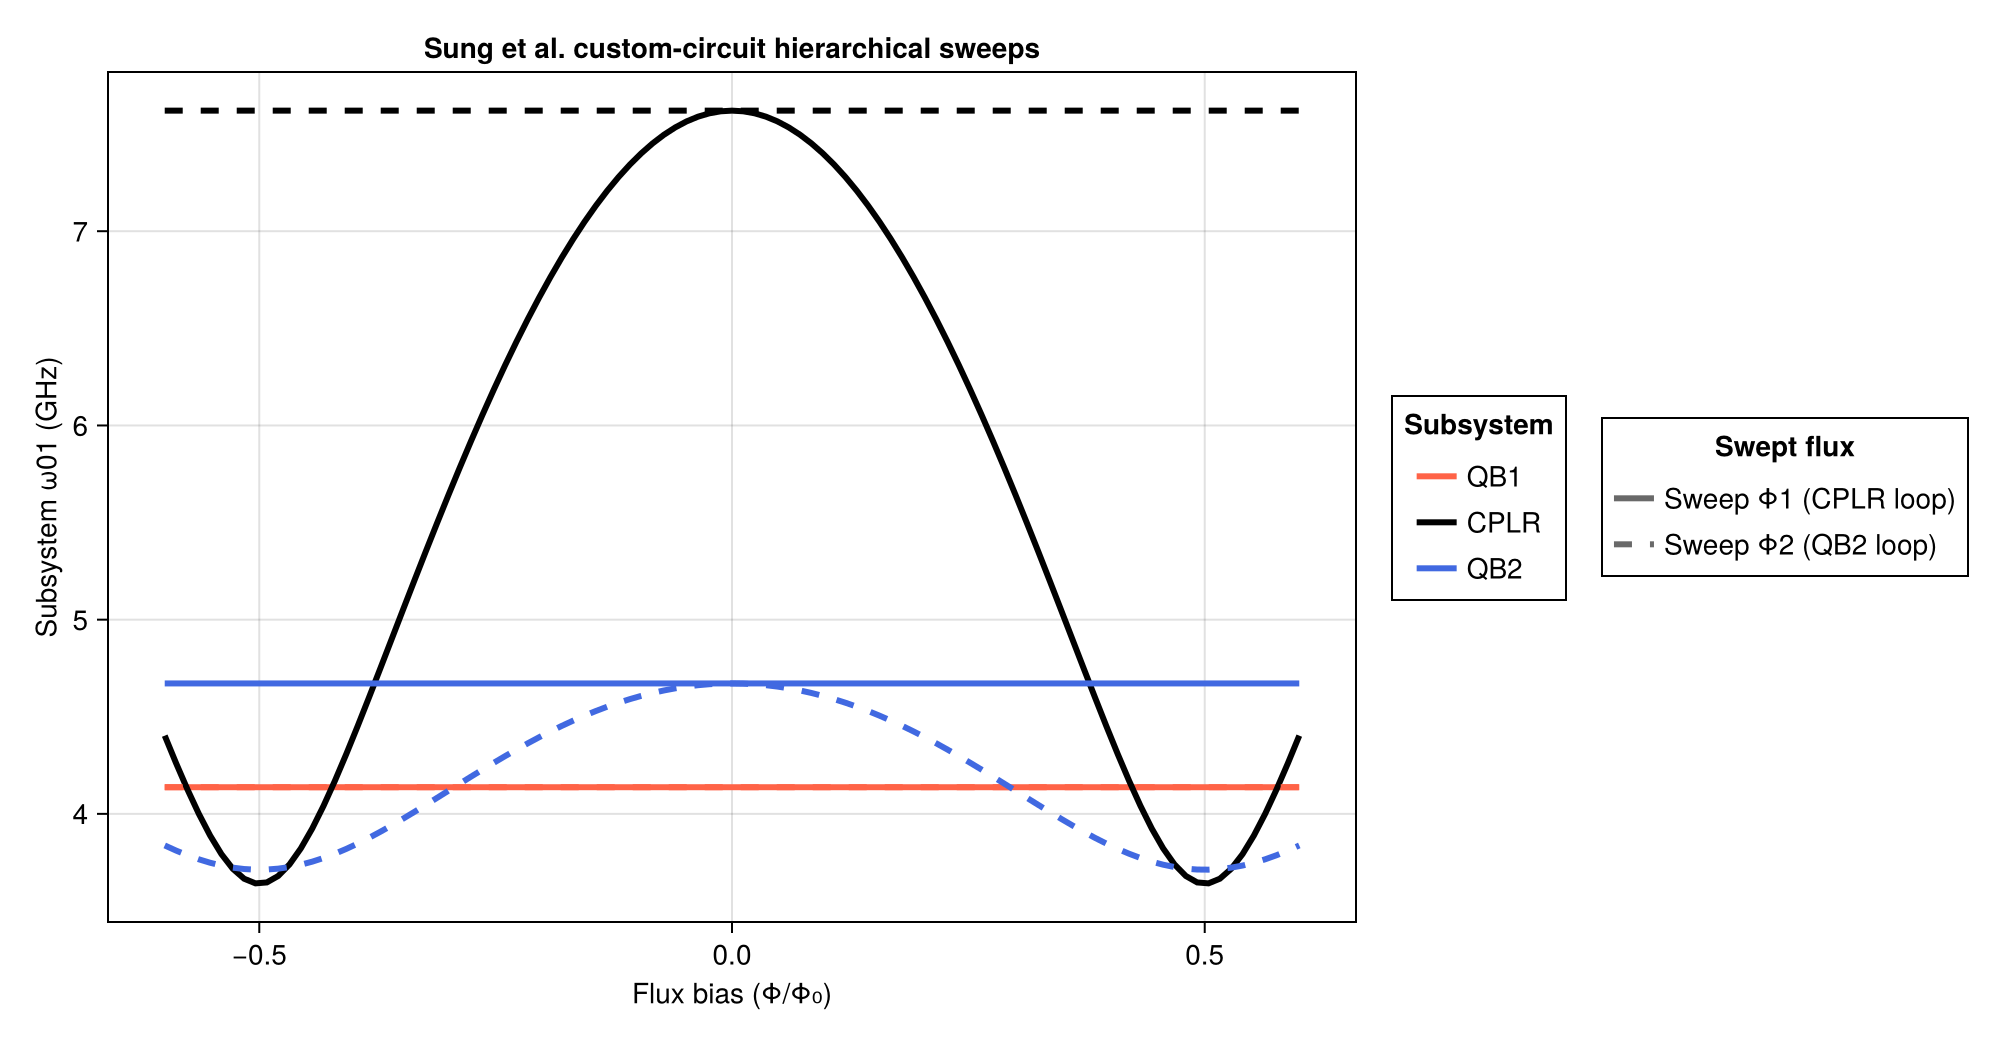

In [9]:
fig = Figure(size=(1000, 520))
ax = Axis(fig[1, 1];
    xlabel="Flux bias (Φ/Φ₀)",
    ylabel="Subsystem ω01 (GHz)",
    title="Sung et al. custom-circuit hierarchical sweeps")

colors = Dict(:qb1 => :tomato, :cplr => :black, :qb2 => :royalblue)
linestyles = Dict(:cplr => :solid, :qb2 => :dash)
labels = Dict(:qb1 => "QB1", :cplr => "CPLR", :qb2 => "QB2")

for rows in (sweep_cplr, sweep_qb2)
    sweep_name = rows[1].swept
    xs = getfield.(rows, :flux_bias)
    for field in (:qb1, :cplr, :qb2)
        ys = getfield.(rows, field)
        lines!(ax, xs, ys; color=colors[field], linestyle=linestyles[sweep_name], linewidth=3)
    end
end

color_legend = [LineElement(color=colors[field], linewidth=3) for field in (:qb1, :cplr, :qb2)]
style_legend = [LineElement(color=:dimgray, linestyle=linestyles[name], linewidth=3) for name in (:cplr, :qb2)]

Legend(fig[1, 2], color_legend, [labels[field] for field in (:qb1, :cplr, :qb2)], "Subsystem")
Legend(fig[1, 3], style_legend, ["Sweep Φ1 (CPLR loop)", "Sweep Φ2 (QB2 loop)"], "Swept flux")

fig


## Frequency-Axis Construction For The 2D ZZ Analysis

The 2D `ZZ` map is computed on a single `Φ1 × Φ2` grid but displayed in **subsystem-frequency coordinates**:

- x-axis: CPLR subsystem `ω01`
- y-axis: QB2 subsystem `ω01`

Because `QB1` is fixed in this model, the later 1D resonant slice is selected by choosing the QB2-frequency row closest to the fixed QB1 subsystem `ω01`.


In [10]:
phi1_vals = DEFAULT_PHI1_GRID
phi2_vals = DEFAULT_PHI2_GRID

phi1_axis_sweep = sweep_subsystem_w01s(COUPLER_FLUX_PARAM, phi1_vals)
phi2_axis_sweep = sweep_subsystem_w01s(QB2_FLUX_PARAM, phi2_vals)

cplr_freq_axis = phi1_axis_sweep.cplr
qb2_freq_axis = phi2_axis_sweep.qb2
qb1_axis_samples = vcat(phi1_axis_sweep.qb1, phi2_axis_sweep.qb1)
qb1_fixed_freq = mean(qb1_axis_samples)
qb1_span_MHz = (maximum(qb1_axis_samples) - minimum(qb1_axis_samples)) * 1000

@assert monotonic_direction(cplr_freq_axis) != :nonmonotonic
@assert monotonic_direction(qb2_freq_axis) != :nonmonotonic
@assert qb1_span_MHz < 1e-3
@assert minimum(qb2_freq_axis) <= qb1_fixed_freq <= maximum(qb2_freq_axis)

axis_summary = (
    external_fluxes = external_fluxes(circ1),
    qb1_fixed_freq_GHz = qb1_fixed_freq,
    qb1_span_MHz = qb1_span_MHz,
    cplr_frequency_window_GHz = extrema(cplr_freq_axis),
    qb2_frequency_window_GHz = extrema(qb2_freq_axis),
    cplr_axis_direction = monotonic_direction(cplr_freq_axis),
    qb2_axis_direction = monotonic_direction(qb2_freq_axis),
    grid_size = (length(phi1_vals), length(phi2_vals)),
)

axis_summary


(external_fluxes = Symbolics.Num[Φ1, Φ2], qb1_fixed_freq_GHz = 4.13738328787574, qb1_span_MHz = 0.0, cplr_frequency_window_GHz = (3.640750853071049, 7.620785599076498), qb2_frequency_window_GHz = (3.7127126420199374, 4.671706001032074), cplr_axis_direction = :increasing, qb2_axis_direction = :increasing, grid_size = (81, 81))

## 2D Exact ZZ Map

The full `Φ1 × Φ2` grid is computed once with `ParameterSweep(...; store_lookups=true, ignore_low_overlap=true)`. The heatmap is shown in subsystem-frequency coordinates and colored by the exact dressed-spectrum `ζ / 2π = χ₁₃ = E101 - E100 - E001 + E000`.

The colormap uses a **symmetric asinh transform** so that both near-zero structure and the larger hybridized regions remain visible on one figure. Colorbar tick labels are still reported in physical `kHz`.


In [11]:
zz_sweep, zz_grid_GHz, lookup_grid = parameter_sweep_zz_qb1_qb2(phi1_vals, phi2_vals)
zz_grid_kHz = zz_grid_GHz .* 1e6

sample_indices = [
    (1, 1),
    (length(phi1_vals) ÷ 2 + 1, length(phi2_vals) ÷ 2 + 1),
    (length(phi1_vals), length(phi2_vals)),
]

sample_validation = [
    let lookup = lookup_grid[i, j],
        zz_lookup = zz_from_lookup(lookup),
        zz_chi = zz_grid_GHz[i, j]
        @assert isapprox(zz_lookup, zz_chi; atol=1e-12, rtol=0.0)
        (
            grid_index = (i, j),
            flux_cplr = phi1_vals[i],
            flux_qb2 = phi2_vals[j],
            zz_from_chi_GHz = zz_chi,
            zz_from_dressed_energies_GHz = zz_lookup,
        )
    end
    for (i, j) in sample_indices
]

resonant_row_idx = argmin(abs.(qb2_freq_axis .- qb1_fixed_freq))
resonant_qb2_freq_GHz = qb2_freq_axis[resonant_row_idx]
resonant_detuning_MHz = (resonant_qb2_freq_GHz - qb1_fixed_freq) * 1000
resonant_cplr_freq_GHz = cplr_freq_axis
resonant_zz_kHz = vec(zz_grid_kHz[:, resonant_row_idx])

peak_idx = argmax(abs.(resonant_zz_kHz))
peak_cplr_freq_GHz = resonant_cplr_freq_GHz[peak_idx]
peak_zz_kHz = resonant_zz_kHz[peak_idx]

zz_limit_kHz = max(maximum(abs, zz_grid_kHz), maximum(abs, ZZ_COLORBAR_TICKS_KHZ))
color_limit = asinh_zz(zz_limit_kHz)
colorbar_tick_positions = asinh_zz.(ZZ_COLORBAR_TICKS_KHZ)
colorbar_tick_labels = [@sprintf("%g", tick) for tick in ZZ_COLORBAR_TICKS_KHZ]

sweep_summary = (
    param_order = zz_sweep.param_order,
    grid_shape = size(zz_grid_GHz),
    resonant_row_idx = resonant_row_idx,
    resonant_qb2_freq_GHz = resonant_qb2_freq_GHz,
    resonant_detuning_MHz = resonant_detuning_MHz,
    zz_window_kHz = extrema(zz_grid_kHz),
    peak_cplr_freq_GHz = peak_cplr_freq_GHz,
    peak_zz_kHz = peak_zz_kHz,
    sample_validation = sample_validation,
)

sweep_summary


(param_order = [:Φ1, :Φ2], grid_shape = (81, 81), resonant_row_idx = 34, resonant_qb2_freq_GHz = 4.138133707504873, resonant_detuning_MHz = 0.7504196291332477, zz_window_kHz = (-202947.72782708038, 149599.65728546365), peak_cplr_freq_GHz = 4.18437939109257, peak_zz_kHz = -200420.3402859801, sample_validation = [(grid_index = (1, 1), flux_cplr = -0.5, flux_qb2 = -0.5, zz_from_chi_GHz = -0.0060682349093355015, zz_from_dressed_energies_GHz = -0.0060682349093355015), (grid_index = (41, 41), flux_cplr = -0.25, flux_qb2 = -0.25, zz_from_chi_GHz = 6.230857260902667e-5, zz_from_dressed_energies_GHz = 6.230857260902667e-5), (grid_index = (81, 81), flux_cplr = 0.0, flux_qb2 = 0.0, zz_from_chi_GHz = -1.3700302815777832e-5, zz_from_dressed_energies_GHz = -1.3700302815777832e-5)])

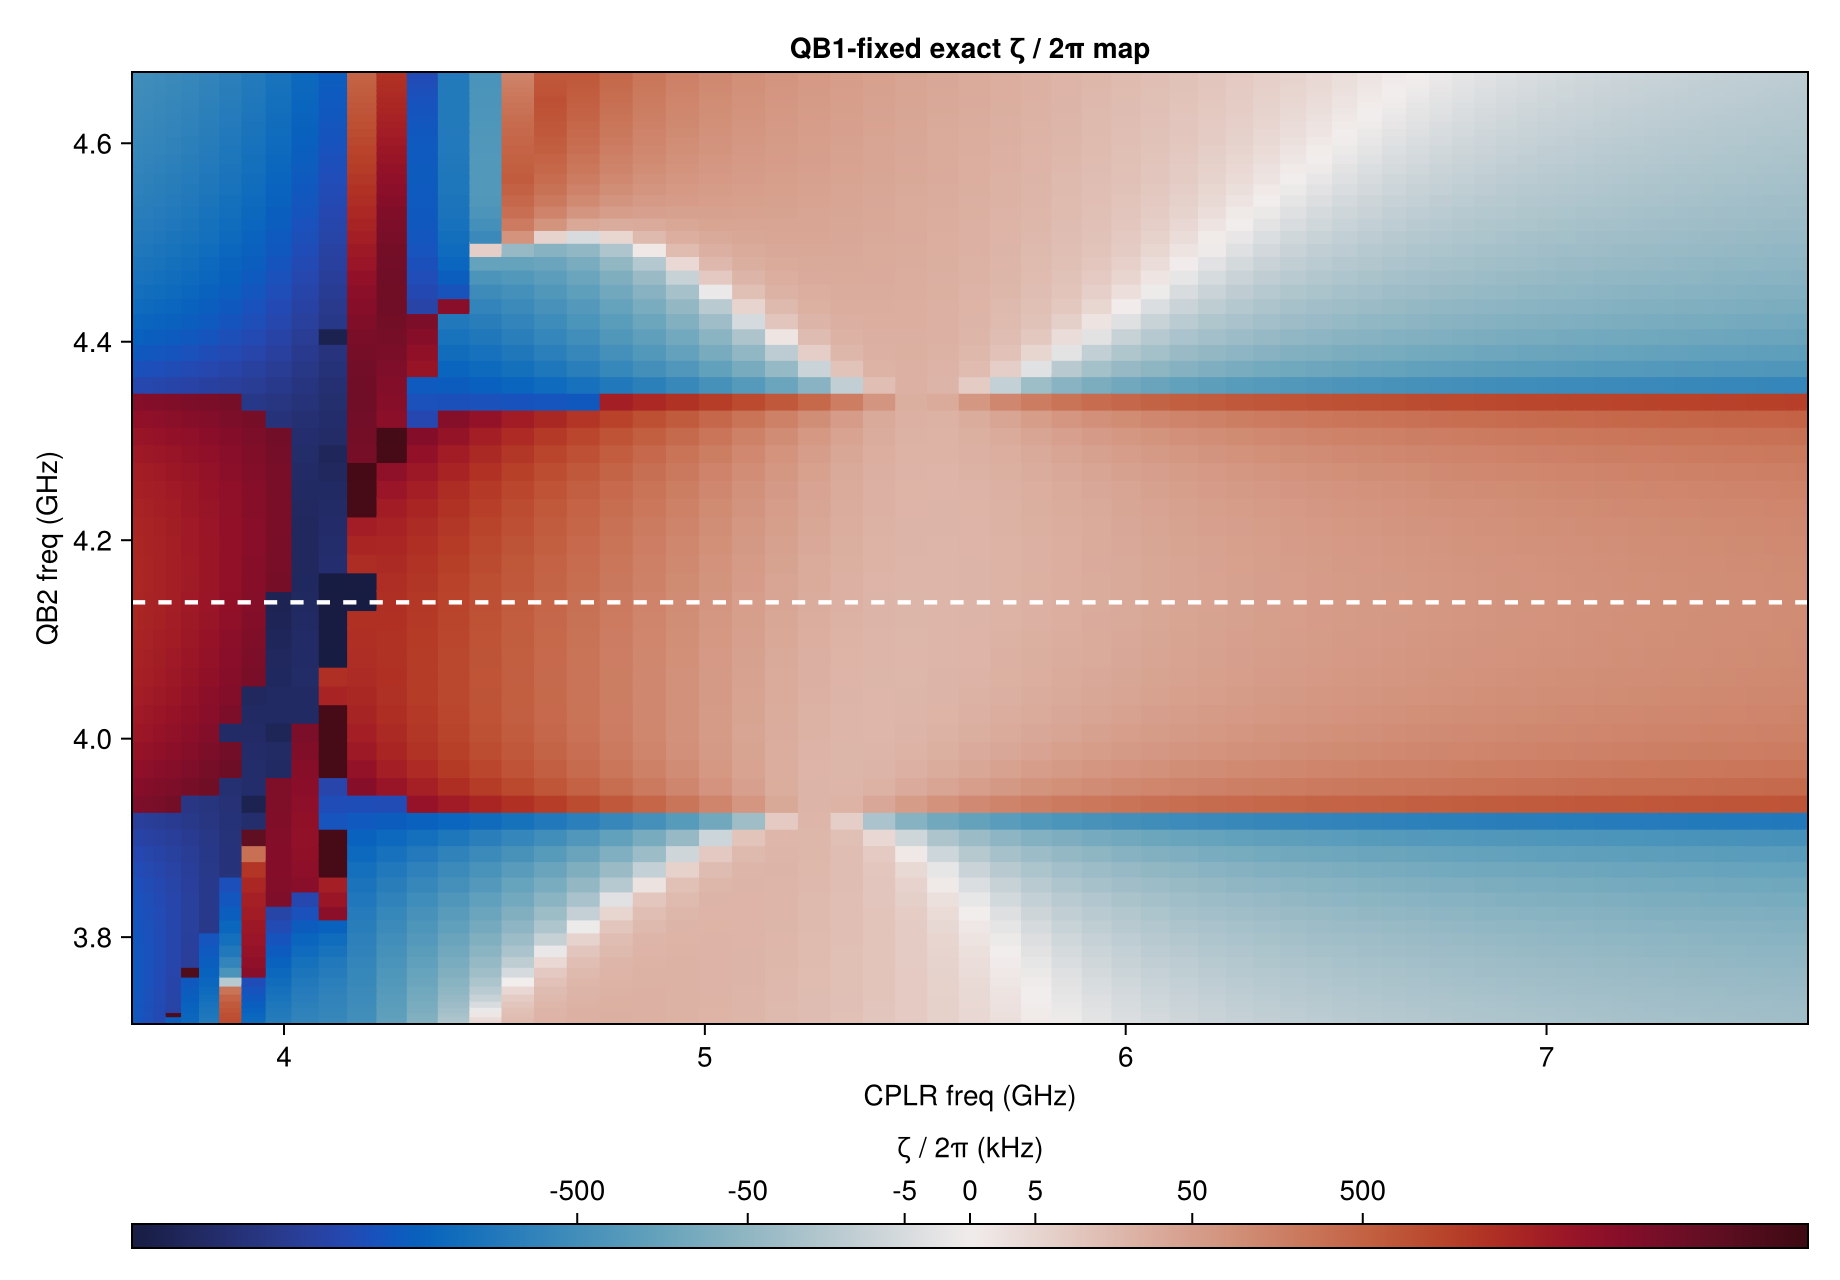

In [12]:
fig_heatmap = Figure(size=(920, 640))
ax_heatmap = Axis(fig_heatmap[1, 1],
    xlabel="CPLR freq (GHz)",
    ylabel="QB2 freq (GHz)",
    title="QB1-fixed exact ζ / 2π map")

hm = heatmap!(ax_heatmap,
    cplr_freq_axis,
    qb2_freq_axis,
    asinh_zz.(zz_grid_kHz);
    colormap=:balance,
    colorrange=(-color_limit, color_limit))

hlines!(ax_heatmap, [qb1_fixed_freq]; color=:white, linestyle=:dash, linewidth=2.2)

Colorbar(fig_heatmap[2, 1], hm;
    vertical=false,
    label="ζ / 2π (kHz)",
    ticks=(colorbar_tick_positions, colorbar_tick_labels))

rowgap!(fig_heatmap.layout, 12)
fig_heatmap


## Grid-Derived Resonant ZZ Slice

The 1D “resonant” trace is not generated by a separate retuning search. It is the row of the 2D map whose QB2 subsystem `ω01` is closest to the fixed QB1 subsystem `ω01`, which keeps the 1D view and 2D heatmap consistent by construction.


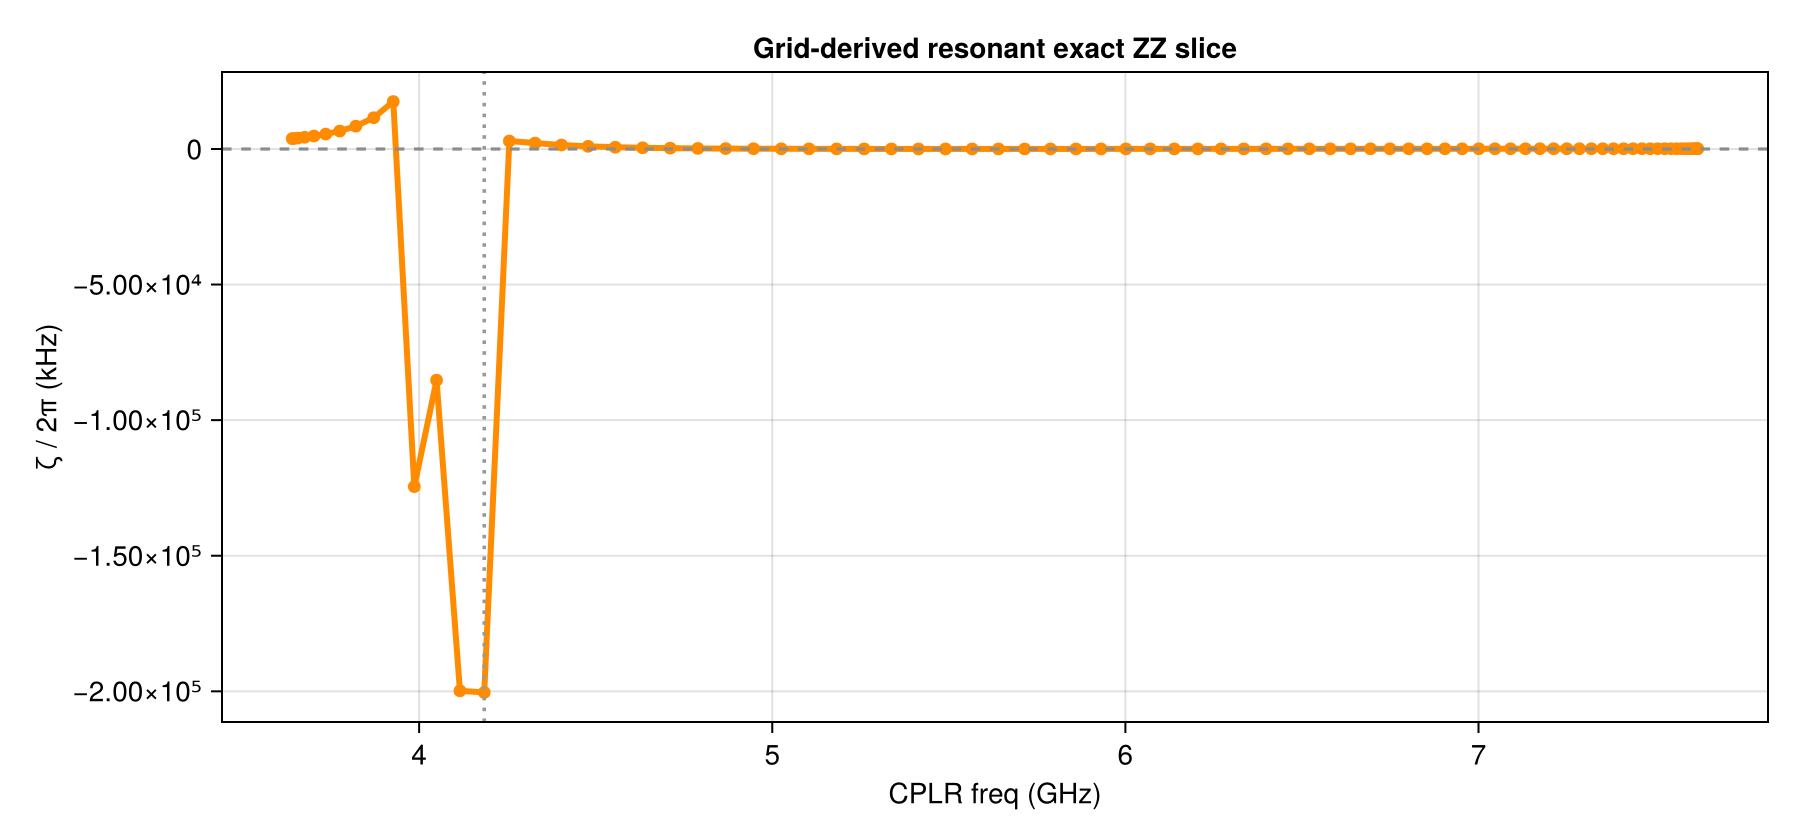

In [13]:
resonant_summary = (
    qb1_fixed_freq_GHz = qb1_fixed_freq,
    selected_qb2_freq_GHz = resonant_qb2_freq_GHz,
    resonance_mismatch_MHz = resonant_detuning_MHz,
    cplr_frequency_window_GHz = extrema(resonant_cplr_freq_GHz),
    resonant_zz_window_kHz = extrema(resonant_zz_kHz),
)

fig_resonant = Figure(size=(900, 420))
ax_resonant = Axis(fig_resonant[1, 1],
    xlabel="CPLR freq (GHz)",
    ylabel="ζ / 2π (kHz)",
    title="Grid-derived resonant exact ZZ slice")

lines!(ax_resonant, resonant_cplr_freq_GHz, resonant_zz_kHz; color=:darkorange, linewidth=3)
scatter!(ax_resonant, resonant_cplr_freq_GHz, resonant_zz_kHz; color=:darkorange, markersize=9)
hlines!(ax_resonant, [0.0]; color=:gray55, linestyle=:dash, linewidth=1.6)
vlines!(ax_resonant, [peak_cplr_freq_GHz]; color=:gray60, linestyle=:dot, linewidth=1.8)

fig_resonant


## One-Excitation Dressed Eigenergy Spectrum Along The Same Resonant Row

The spectrum below reuses the same grid row selected for the resonant `ZZ` slice. For each CPLR-frequency point, it takes the one-excitation dressed eigenergies associated with the bare labels `|100⟩`, `|010⟩`, and `|001⟩`, then sorts them into the lower, middle, and upper exact dressed branches.

That representation is what makes the avoided crossing visible. These curves are exact adiabatic branches along the selected row; they are intentionally different from bare-label tracking, which would follow dominant state character and can swap identity through the hybridized region.



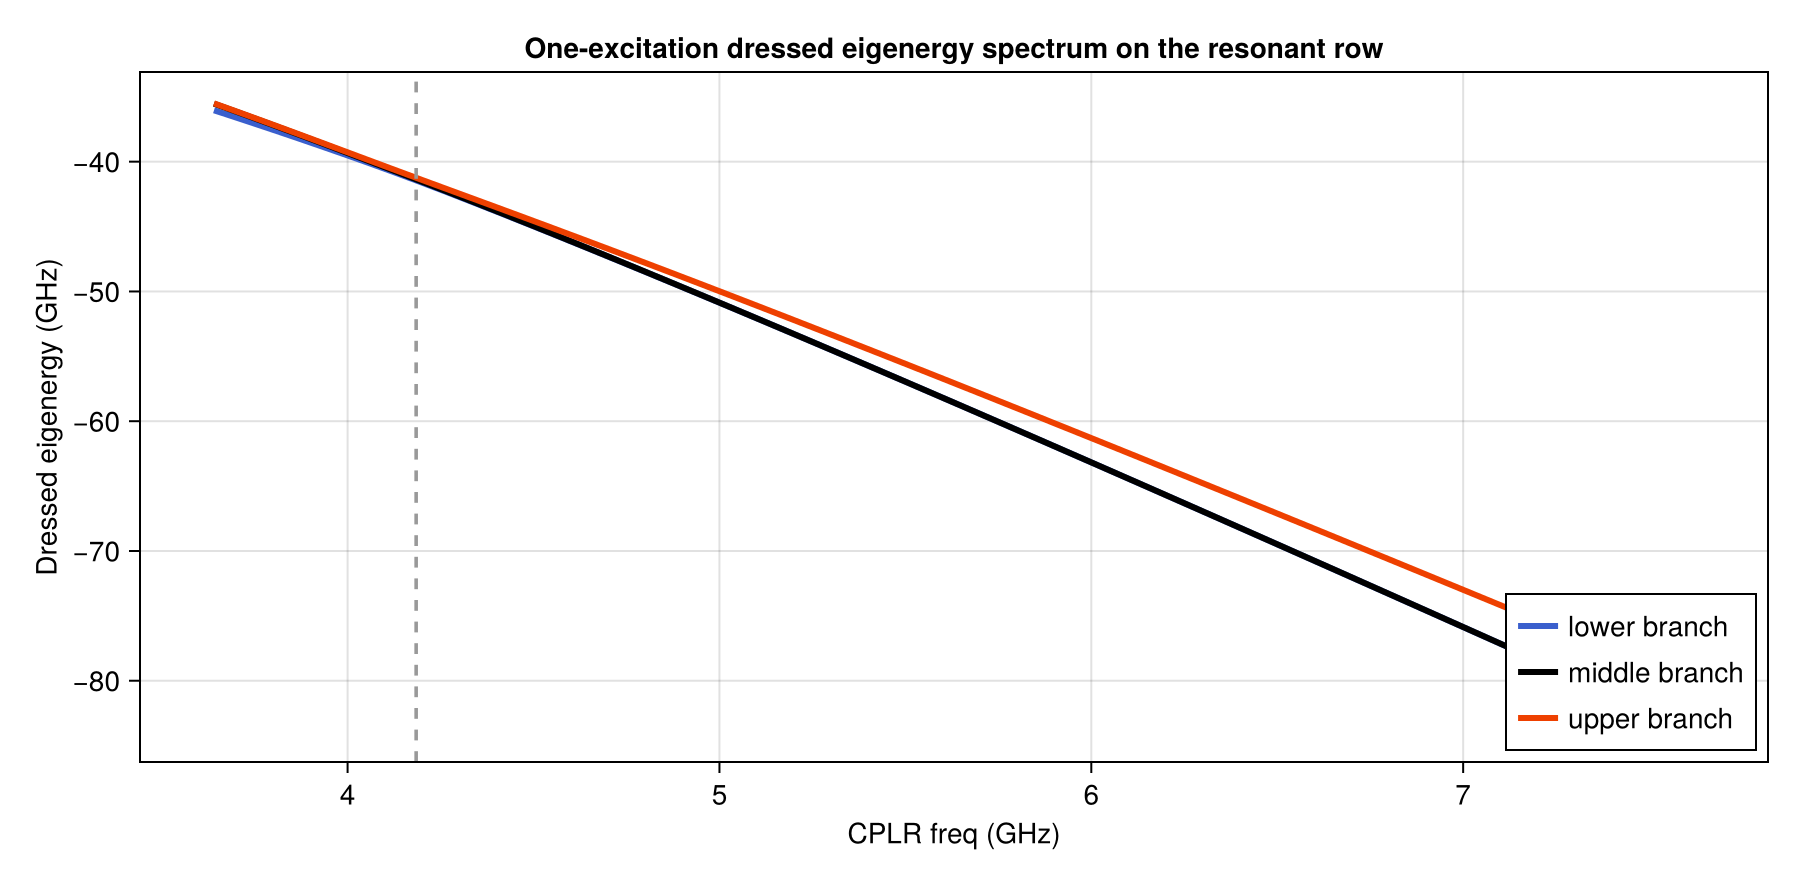

In [14]:
resonant_lookup_row = lookup_grid[:, resonant_row_idx]
q1_eigenergy_GHz = [lookup_energy(lookup, Q1_LABEL) for lookup in resonant_lookup_row]
cplr_eigenergy_GHz = [lookup_energy(lookup, CPLR_LABEL) for lookup in resonant_lookup_row]
q2_eigenergy_GHz = [lookup_energy(lookup, Q2_LABEL) for lookup in resonant_lookup_row]

sorted_manifold = [sort([q1_eigenergy_GHz[i], cplr_eigenergy_GHz[i], q2_eigenergy_GHz[i]])
                   for i in eachindex(resonant_cplr_freq_GHz)]
branch_low_GHz = first.(sorted_manifold)
branch_mid_GHz = getindex.(sorted_manifold, 2)
branch_high_GHz = last.(sorted_manifold)

fig_spectrum = Figure(size=(900, 440))
ax_spectrum = Axis(fig_spectrum[1, 1],
    xlabel="CPLR freq (GHz)",
    ylabel="Dressed eigenergy (GHz)",
    title="One-excitation dressed eigenergy spectrum on the resonant row")

lines!(ax_spectrum, resonant_cplr_freq_GHz, branch_low_GHz; color=:royalblue3, linewidth=3, label="lower branch")
lines!(ax_spectrum, resonant_cplr_freq_GHz, branch_mid_GHz; color=:black, linewidth=3, label="middle branch")
lines!(ax_spectrum, resonant_cplr_freq_GHz, branch_high_GHz; color=:orangered2, linewidth=3, label="upper branch")
vlines!(ax_spectrum, [peak_cplr_freq_GHz]; color=:gray60, linestyle=:dash, linewidth=1.8)
axislegend(ax_spectrum, position=:rb)

fig_spectrum


## Results And Notes

- The notebook now computes one shared `Φ₁ × Φ₂` dataset and uses it for the 2D heatmap, the 1D resonant slice, and the avoided-crossing spectrum.
- The heatmap is plotted in **subsystem-frequency coordinates**, not flux coordinates.
- The 1D resonant slice is the QB2-frequency row closest to the fixed QB1 subsystem `ω₀₁`; it is no longer produced by an online coarse/refine retuning search.
- The colormap is **nonlinear**: values are transformed with a symmetric asinh scale before plotting, while the colorbar tick labels remain in physical `kHz`.
- The spectrum panel uses **energy-sorted one-excitation dressed branches** along the same resonant row, so the avoided crossing is visible where `|ζ|` is largest.
- Any label-derived effective quantity or resonance interpretation should be treated cautiously in the strongly hybridized region; there the dressed eigenspectrum is the authoritative description.

